# Random Simplicial Complexes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd


from itertools import combinations
from collections import defaultdict
import random
import petls

# For random experiments replication
seed = 1



## Algorithms

**NOTE:** The algoritm to generate a random simpicial complex was never implemented, only designed for building the random pair generator.

### Generate a random pair

In [2]:
def faces(simplex):
    """All non-empty faces of a simplex."""
    simplex = tuple(simplex)
    out = set()
    for r in range(1, len(simplex) + 1):
        out.update(combinations(simplex, r))
    return out


def add_simplex(K, simplex):
    """Add simplex and all its faces to K."""
    K.update(faces(simplex))


def random_pair_complex(max_dim, vertices, m, seed=None):
    """
    Generate two random simplicial complexes K1, K2 with K2 subset K1.

    max_dim: maximum simplex dimension
    vertices: list of vertices, e.g. [0,1,2,3,4]
    m: list [m_0, ..., m_n], max number of simplices sampled per dimension

    """
    if seed is not None:
        random.seed(seed)

    K1 = set()
    K2 = set()

    for k in range(max_dim, -1, -1):
        r = random.randint(0, m[k])

        possible_simplices = list(combinations(vertices, k + 1))

        for _ in range(r):
            sigma = random.choice(possible_simplices)

            add_simplex(K1, sigma)

            if random.random() <= 0.5:
                add_simplex(K2, sigma)

    return K1, K2

**Example**

In [3]:
V = [0, 1, 2, 3, 4]
m = [5, 5, 3]  # max vertices, edges, triangles

K1, K2 = random_pair_complex(
    max_dim=2,
    vertices=V,
    m=m,
    seed=seed
)

print("K1 =", K1)
print("K2 =", K2)
print("K2 subset K1?", K2.issubset(K1))

K1 = {(2, 4), (2,), (3, 4), (4,), (2, 3), (2, 3, 4), (0,), (3,)}
K2 = {(0,), (3,)}
K2 subset K1? True


### Random pairs to boundary matrices and filtration lists

In [ ]:
import numpy as np


def order_simplices_by_dimension(K1, K2, max_dim):
    """
    Return ordered lists S_0,...,S_n of simplices of K1.

    Important for PETLS:
    simplices in K2 must come first, then simplices in K1 \ K2.
    """
    K1 = {tuple(sorted(sigma)) for sigma in K1}
    K2 = {tuple(sorted(sigma)) for sigma in K2}

    simplices = []

    for k in range(max_dim + 1):
        S_k = [sigma for sigma in K1 if len(sigma) == k + 1]

        # PETLS-compatible order: filtration 0 first, then filtration 1
        S_k = sorted(S_k, key=lambda sigma: (0 if sigma in K2 else 1, sigma))

        simplices.append(S_k)

    return simplices

"""
NOT PETLS COMPATIBLE:
def order_simplices_by_dimension(K, max_dim):
    ""
    Return ordered lists S_0,...,S_n of simplices of K.
    ""
    K = {tuple(sorted(sigma)) for sigma in K}

    simplices = []

    for k in range(max_dim + 1):
        S_k = sorted([sigma for sigma in K if len(sigma) == k + 1])
        simplices.append(S_k)

    return simplices
"""


def boundary_matrix(S_prev, S_curr):
    """
    Build d_k : C_k -> C_{k-1}.

    Rows correspond to S_prev.
    Columns correspond to S_curr.
    """
    d = np.zeros((len(S_prev), len(S_curr)), dtype=int)

    face_index = {sigma: i for i, sigma in enumerate(S_prev)}

    for j, sigma in enumerate(S_curr):
        sigma = tuple(sigma)

        for i in range(len(sigma)):
            face = sigma[:i] + sigma[i + 1:]
            row = face_index[face]
            d[row, j] = (-1) ** i

    return d


def pair_to_boundary_filtration(K1, K2, max_dim):
    """
    Convert K2 subset K1 into PETLS inputs:

        boundaries = [d_1,...,d_n]
        filtrations = [F_0,...,F_n]
    """
    K1 = {tuple(sorted(sigma)) for sigma in K1}
    K2 = {tuple(sorted(sigma)) for sigma in K2}

    if not K2.issubset(K1):
        raise ValueError("K2 must be a subset of K1.")

    simplices = order_simplices_by_dimension(K1, K2, max_dim)

    boundaries = []

    for k in range(1, max_dim + 1):
        d_k = boundary_matrix(simplices[k - 1], simplices[k])
        boundaries.append(d_k)

    filtrations = []

    for k in range(max_dim + 1):
        F_k = [0 if sigma in K2 else 1 for sigma in simplices[k]]
        filtrations.append(F_k)

    return boundaries, filtrations, simplices

**Full example computing spectra with PELTS**

In [15]:
max_dim = 3
vertices = [1, 2, 3, 4, 5, 6, 7]
m = [2, 2, 3, 5]
seed = 1

K1, K2 = random_pair_complex(max_dim=max_dim, vertices=vertices, m=m, seed=seed)

boundaries, filtrations, simplices = pair_to_boundary_filtration(K1, K2, max_dim)

print("K2 subset K1")
print("K1 =", sorted(K1, key=lambda x: (len(x), x)))
print("K2 =", sorted(K2, key=lambda x: (len(x), x)))

print("\nOrdered simplices K1:")
for k, S_k in enumerate(simplices):
    print(f"S_{k} =", S_k)

print("\nBoundary matrices:")
for k, d_k in enumerate(boundaries, start=1):
    print(f"d_{k} =")
    print(d_k)

print("\nFiltration lists:")
for k, F_k in enumerate(filtrations):
    print(f"F_{k} =", F_k)

# PETLS complex
K_petls = petls.Complex(boundaries, filtrations)

for i in range(max_dim + 1):
    print(f"\nSpectrum Δ_{i}^{0,1}:")
    print(K_petls.spectra(dim=i, a=0, b=1))


K2 subset K1
K1 = [(1,), (2,), (3,), (4,), (5,), (6,), (7,), (1, 2), (1, 3), (1, 4), (1, 5), (2, 4), (2, 5), (2, 6), (2, 7), (3, 5), (3, 6), (4, 5), (5, 6), (6, 7), (1, 2, 4), (1, 2, 5), (1, 3, 5), (1, 4, 5), (2, 4, 5), (2, 6, 7), (3, 5, 6), (1, 2, 4, 5)]
K2 = [(1,), (2,), (3,), (4,), (5,), (6,), (1, 2), (1, 3), (1, 4), (1, 5), (2, 4), (2, 5), (3, 5), (3, 6), (4, 5), (5, 6), (1, 2, 4), (1, 2, 5), (1, 3, 5), (1, 4, 5), (2, 4, 5), (3, 5, 6), (1, 2, 4, 5)]

Ordered simplices K1:
S_0 = [(1,), (2,), (3,), (4,), (5,), (6,), (7,)]
S_1 = [(1, 2), (1, 3), (1, 4), (1, 5), (2, 4), (2, 5), (3, 5), (3, 6), (4, 5), (5, 6), (2, 6), (2, 7), (6, 7)]
S_2 = [(1, 2, 4), (1, 2, 5), (1, 3, 5), (1, 4, 5), (2, 4, 5), (3, 5, 6), (2, 6, 7)]
S_3 = [(1, 2, 4, 5)]

Boundary matrices:
d_1 =
[[-1 -1 -1 -1  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0 -1 -1  0  0  0  0 -1 -1  0]
 [ 0  1  0  0  0  0 -1 -1  0  0  0  0  0]
 [ 0  0  1  0  1  0  0  0 -1  0  0  0  0]
 [ 0  0  0  1  0  1  1  0  1 -1  0  0  0]
 [ 0  0  0  0  0  

### Time analysis of the algoritms

Now we want to know the complexity with bigger simplices. For that we use a constant ``m`` for all dimensions and ``v`` as the number of vertices and increse them. We also increaso the maximum dimension.

**``m = v = 10`` and ``max_dim = 5``**

In [6]:
m = v = 10
max_dim = 5


# timer init
t0 = time.perf_counter()

# ---
vertices = list(range(1, v + 1))
m = [m] * (max_dim + 1)

K1, K2 = random_pair_complex( max_dim=max_dim, vertices=vertices, m=m,seed=seed)

boundaries, filtrations, _ = pair_to_boundary_filtration(K1, K2, max_dim)

K_petls = petls.Complex(boundaries, filtrations)

for i in range(max_dim):
    K_petls.spectra(dim=i, a=0, b=1)
# ---

# timer end
total_time = time.perf_counter() - t0
print(f"\nTotal time: {total_time:.6f} seconds")


Total time: 0.013606 seconds


We want to create samples in less that 2 seconds.

In [7]:
import time

m_const = 10
v = 10
max_dim = 5

while True:
    t0 = time.perf_counter()

    vertices = list(range(1, v + 1))
    m = [m_const] * (max_dim + 1)

    K1, K2 = random_pair_complex(
        max_dim=max_dim,
        vertices=vertices,
        m=m,
        seed=seed
    )

    boundaries, filtrations, simplices = pair_to_boundary_filtration(
        K1, K2, max_dim
    )

    K_petls = petls.Complex(boundaries, filtrations)

    for i in range(max_dim):
        K_petls.spectra(dim=i, a=0, b=1)

    total_time = time.perf_counter() - t0

    print(f"v = {v}, m = {m_const}, time = {total_time:.4f} seconds")

    if total_time > 1:
        print(f"Final v = {v}")
        print(f"Final m = {m_const}")


        print("\nNumber of simplices by dimension:")
        for k, S_k in enumerate(simplices):
            print(f"dim {k}: {len(S_k)} simplices")

        break

    v += 1
    m_const += 1

v = 10, m = 10, time = 0.0101 seconds
v = 11, m = 11, time = 0.0061 seconds
v = 12, m = 12, time = 0.0071 seconds
v = 13, m = 13, time = 0.0048 seconds
v = 14, m = 14, time = 0.0112 seconds
v = 15, m = 15, time = 0.0083 seconds
v = 16, m = 16, time = 0.0148 seconds
v = 17, m = 17, time = 0.0098 seconds
v = 18, m = 18, time = 0.0145 seconds
v = 19, m = 19, time = 0.0203 seconds
v = 20, m = 20, time = 0.0200 seconds
v = 21, m = 21, time = 0.0210 seconds
v = 22, m = 22, time = 0.0226 seconds
v = 23, m = 23, time = 0.0356 seconds
v = 24, m = 24, time = 0.0367 seconds
v = 25, m = 25, time = 0.0505 seconds
v = 26, m = 26, time = 0.0566 seconds
v = 27, m = 27, time = 0.0645 seconds
v = 28, m = 28, time = 0.0817 seconds
v = 29, m = 29, time = 0.1083 seconds
v = 30, m = 30, time = 0.1428 seconds
v = 31, m = 31, time = 0.1777 seconds
v = 32, m = 32, time = 0.2463 seconds
v = 33, m = 33, time = 0.2958 seconds
v = 34, m = 34, time = 0.3022 seconds
v = 35, m = 35, time = 0.4675 seconds
v = 36, m = 

This is still biased to a particular structure. But we will work with it. To work with good numbers we will use ``v = m = 45`` and ``dim = 5``.

## Collect the nonzero spectra at each dimension

Same generation and parameters as the dataset ($45$ vertices, maximum dimension $5$, $50$ pairs), but we keep only the nonzero eigenvalues of the persistent Laplacian at each dimension.

In [16]:
# Same generation as the dataset with the same parameters
max_dim = 5
n_vertices = 45
vertices = list(range(1, n_vertices + 1))
m = [n_vertices] * (max_dim + 1)
n_samples = 50
tol = 1e-3

nz = defaultdict(list)
for seed in range(n_samples):
    K1, K2 = random_pair_complex(max_dim=max_dim, vertices=vertices, m=m, seed=seed)
    boundaries, filtrations, _ = pair_to_boundary_filtration(K1, K2, max_dim)
    K_petls = petls.Complex(boundaries, filtrations)
    for k in range(max_dim + 1):
        eigs = np.array(K_petls.spectra(dim=k, a=0, b=1), dtype=float)
        nz[k].extend(eigs[np.abs(eigs) > tol].tolist())


## Number of integers per dimension

In [9]:
# number of integer eigenvalues per dimension
for k in range(max_dim + 1):
    a = np.array(nz[k])
    n_int = int(np.sum(np.abs(a - np.round(a)) < 1e-2))
    print(f"dim {k}: {n_int} integers out of {len(a)} nonzero eigenvalues")


dim 0: 53 integers out of 2179 nonzero eigenvalues
dim 1: 3846 integers out of 14156 nonzero eigenvalues
dim 2: 14089 integers out of 19507 nonzero eigenvalues
dim 3: 11870 integers out of 12042 nonzero eigenvalues
dim 4: 4073 integers out of 4073 nonzero eigenvalues
dim 5: 585 integers out of 585 nonzero eigenvalues


## Integer percentage per dimension

In [17]:
# integer percentage per dimension, as a table
rows = []
for k in range(max_dim + 1):
    a = np.array(nz[k])
    pct = 100 * np.mean(np.abs(a - np.round(a)) < 1e-2)
    rows.append({"dimension": k, "integer %": round(pct, 1)})

integer_table = pd.DataFrame(rows).set_index("dimension")
integer_table


,integer %
dimension,
0,2.4
1,27.2
2,72.2
3,98.6
4,100.0
5,100.0


## Figure: eigenvalues per dimension

One panel per dimension, running from $0$ to $5$ left to right, top to bottom.

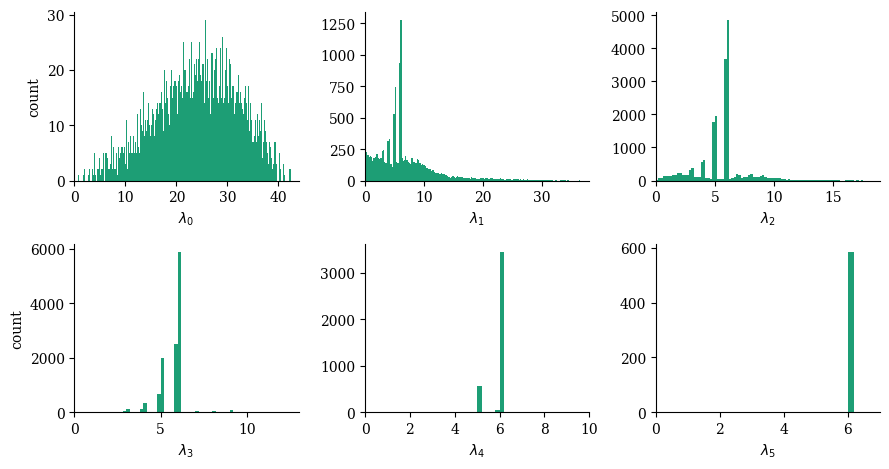

In [11]:
GREEN = "#1D9E75"
plt.rcParams.update({"font.family": "serif",
                     "axes.spines.top": False, "axes.spines.right": False})

fig, axes = plt.subplots(2, 3, figsize=(9, 4.8))
for k, ax in zip(range(max_dim + 1), axes.ravel()):
    a = np.array(nz[k])
    hi = int(np.ceil(a.max())) + 1
    ax.hist(a, bins=np.arange(0, hi + 0.2, 0.2), color=GREEN)
    ax.set_xlim(0, hi)
    ax.set_xlabel(rf"$\lambda_{k}$")
for ax in axes[:, 0]:
    ax.set_ylabel("count")
fig.tight_layout()
fig.savefig("integer_spectra.pdf", bbox_inches="tight")
plt.show()


## Dataset

Here we record the functions developed to create the dataset and the call to generate it, as we belief is the most reusable.

### Properties of simplicial complex and pairs functions

Now we want to compute properties of the simplicial complex and pairs. We will create functions to compute each property based on one of the previous representations and then create a dataset with properties and see the patterns. If we face a size effect as expected we will then normalize.

#### Properties of the simplicial complexes

##### Combinatorial properties

**``Simplicial complex dimension``:**

In [ ]:
def simplex_dim(sigma):
    """Dimension of a simplex."""
    return len(sigma) - 1

def complex_dimension(K):
    """Maximum dimension of the simplicial complex.
    
       Based on the list representation of the simplicial complex.
    """
    if len(K) == 0:
        return -1
    return max(simplex_dim(sigma) for sigma in K)

In [ ]:
K = [(0,), (2,), (3,), (0, 2), (2, 3),]
complex_dimension(K)

1

**``Number of simplices``:**

In [ ]:
def number_simplices(K):
    """Total number of simplices in the simplicial complex."""
    return len(K)

In [ ]:
K = [(0,), (2,), (3,), (0, 2), (2, 3)]

number_simplices(K)

5

**``f-vector``:**

Number of simplices by dimension.

In [ ]:
def simplices_by_dimension(K):
    """Group simplices by dimension."""
    D = {}

    for sigma in K:
        k = simplex_dim(sigma)

        if k not in D:
            D[k] = []

        D[k].append(sigma)

    return D

def f_vector(K):
    """Compute the f-vector of a simplicial complex.
    
    The entry f_k is the number of k-simplices.
    """
    dim = complex_dimension(K)
    D = simplices_by_dimension(K)

    f = []

    for k in range(dim + 1):
        f.append(len(D.get(k, [])))

    return f

In [ ]:
K = [(0,), (2,), (3,), (0, 2), (2, 3)]
f_vector(K)

[3, 2]


**``Number of facets``:**

The facets are the maximal simplices of the complex.

In [ ]:
def facets(K):
    """Maximal simplices of the simplicial complex."""
    F = []

    for sigma in K:
        sigma_set = set(sigma)
        is_facet = True

        for tau in K:
            tau_set = set(tau)

            if sigma_set < tau_set:
                is_facet = False
                break

        if is_facet:
            F.append(sigma)

    return sorted(F, key=lambda x: (len(x), x))

def number_facets(K):
    """Number of maximal simplices of the simplicial complex."""
    return len(facets(K))

In [ ]:
K = [(0,), (1,), (2,), (3,), (0, 2), (2, 3)]

number_facets(K)

3

#### Topological properties

**``betti numbers``**

We still compute the betti numbers to see if they are related with other eigenvalues. For that we use the number of zero eigenvalues of the Hodge Laplacian. 

In [ ]:
max_dim = 5

vertices = list(range(1, 46))
m = [45] * (max_dim + 1)

K1, K2 = random_pair_complex(
    max_dim=max_dim,
    vertices=vertices,
    m=m
)

boundaries, filtrations, simplices = pair_to_boundary_filtration(
    K1, K2, max_dim
)

K_petls = petls.Complex(boundaries, filtrations)

# hodge laplacian dim 1 spectra of each simplicial complex

tol = 1e-3

spectra_K2 = K_petls.spectra(dim=1, a=0, b=0) # K2
spectra_K1 = K_petls.spectra(dim=1, a=1, b=1) # K1

betti_K2 = sum(abs(float(x)) < tol for x in spectra_K2)
betti_K1 = sum(abs(float(x)) < tol for x in spectra_K1)

nonzero_K2 = [float(x) for x in spectra_K2 if abs(float(x)) >= tol]
nonzero_K1 = [float(x) for x in spectra_K1 if abs(float(x)) >= tol]


β_1(K2) = 0
β_1(K1) = 74
spectral gap K2 = 6.0
spectral gap K1 = 0.07412166148424149


**``Euler characteristics:``**

Computational Algebraic Topology book:
$$\chi(K)=\sum_{i=0}^{\dim K}(-1)^i\,\#K_i.$$




In [ ]:
def euler_f(f_vector):
    """
    Compute the Euler characteristic from the f-vector.
    """
    return sum((-1)**k * f_k for k, f_k in enumerate(f_vector))

In [ ]:
f = [4, 5, 1]  # 4 vertices, 5 edges, 1 triangle

chi = euler_f(f)

print(chi)

0


### Properties of the pairs

#### Combinatorial properties

**``Diference of number of simplices``**

In [ ]:
def difference_number_simplices(K1, K2):
    """
    Difference in total number of simplices between K1 and K2.

    Assumes K2 subset K1.
    """
    return number_simplices(K1) - number_simplices(K2)

**``Diference f-vector``**

In [ ]:
def difference_f_vector(K1, K2):
    """
    Difference of f-vectors between K1 and K2.

    Entry k gives the difference in the number of k-simplices.
    """
    f1 = f_vector(K1)
    f2 = f_vector(K2)

    max_len = max(len(f1), len(f2))

    f1 = f1 + [0] * (max_len - len(f1))
    f2 = f2 + [0] * (max_len - len(f2))

    return [f1[k] - f2[k] for k in range(max_len)]

**``Diference number facets``**

In [ ]:
def difference_number_facets(K1, K2):
    """
    Difference in number of maximal simplices between K1 and K2.

    Assumes K2 subset K1.
    """
    return number_facets(K1) - number_facets(K2)

#### Topological properties

**``persistent betti numbers``**

To compute persistent betti numbers we can not use a similiar formula as with betti numbers.

We use the number of zero eigenvalues of the persistent laplacian. Since we will compute the spectra when asking for persistent betti numbers we do as before:

``betti_K1 = sum(abs(float(x)) < tol for x in spectra_K1)``


In [ ]:
n_vertices = m = 45
vertices = list(range(1, n_vertices + 1))
tol = 1e-3

K1, K2 = random_pair_complex(
    max_dim=max_dim,
    vertices=vertices,
    m=[m] * (max_dim + 1),
    seed=seed
)

# Move to PETLS input
boundaries, filtrations, simplices = pair_to_boundary_filtration(
    K1,
    K2,
    max_dim=max_dim,
)

K_petls = petls.Complex(boundaries, filtrations)

eigs = np.array(K_petls.spectra(dim=1, a=0, b=1), dtype=float)

persistent_betti = int(np.sum(np.abs(eigs) <= tol))

print(persistent_betti)


59


A known example with $\beta_1^{0,1}= 1$

In [ ]:
K2 = [
    [1],
    [2],
    [3],
    [1,2],
    [2,3],
    [1,3]
]

K1 = [
    [1],
    [2],
    [3],
    [1,2],
    [2,3],
    [1,3]
]
# Move to PETLS input
boundaries, filtrations, simplices = pair_to_boundary_filtration(
    K1,
    K2,
    max_dim=max_dim,
)

K_petls = petls.Complex(boundaries, filtrations)

eigs = np.array(K_petls.spectra(dim=1, a=0, b=1), dtype=float)

persistent_betti = int(np.sum(np.abs(eigs) <= tol))

print(persistent_betti)

1


### Call to generate the dataset

The samples are going to be pairs of simplicial complex with all their spectra and posible features.
Each row will have:
- Features of K1 and F2
- Features of the pair
- spectra of $\Delta_k^{0,1}$ for $k \in [0, 5]$ (only vector)

We want only numbers, not vectors, to be able to see correlations.

In [ ]:
import numpy as np
import pandas as pd
import petls

# Parameters
n_samples = 50
max_dim = 5
n_vertices = m = 45
vertices = list(range(1, n_vertices + 1))
tol = 1e-3

rows = []

for sample_id in range(n_samples):

    seed = sample_id

    # Generate random pair K2 subset K1
    K1, K2 = random_pair_complex(
        max_dim=max_dim,
        vertices=vertices,
        m=[m] * (max_dim + 1),
        seed=seed
    )

    # Move to PETLS input
    boundaries, filtrations, simplices = pair_to_boundary_filtration(
        K1,
        K2,
        max_dim=max_dim,
    )

    K_petls = petls.Complex(boundaries, filtrations)

    # Generate row
    row = {}

    row["sample_id"] = sample_id


    # ============================================================
    # K1 features
    # ============================================================

    row["K1_n_simplices"] = number_simplices(K1)
    row["K1_n_facets"] = number_facets(K1)

    f1 = f_vector(K1)
    f1 = f1 + [0] * (max_dim + 1 - len(f1))

    for k in range(max_dim + 1):
        row[f"K1_f{k}"] = f1[k]

    row["K1_euler"] = euler_f(f1)

    # Betti numbers of K1
    for k in range(max_dim + 1):
        row[f"K1_betti{k}"] = betti_from_ranks(boundaries, filtrations, k=k, level=1)


    # ============================================================
    # K2 features
    # ============================================================

    row["K2_n_simplices"] = number_simplices(K2)
    row["K2_n_facets"] = number_facets(K2)


    f2 = f_vector(K2)
    f2 = f2 + [0] * (max_dim + 1 - len(f2))

    for k in range(max_dim + 1):
        row[f"K2_f{k}"] = f2[k]

    row["K2_euler"] = euler_f(f2)


    # Betti numbers of K2
    for k in range(max_dim + 1):
        row[f"K2_betti{k}"] = betti_from_ranks(boundaries, filtrations, k=k, level=0)


    # ============================================================
    # Pair features
    # ============================================================

    row["pair_diff_n_simplices"] = number_simplices(K1) - number_simplices(K2)
    row["pair_diff_n_facets"] = number_facets(K1) - number_facets(K2)

    fdiff = [f1[k] - f2[k] for k in range(max_dim + 1)]

    for k in range(max_dim + 1):
        row[f"pair_diff_f{k}"] = fdiff[k]

    row["pair_diff_euler"] = euler_f(fdiff)

    # Persistent Betti numbers and spectra:
    # beta_k^{0,1} = dim ker Delta_k^{0,1}
    for k in range(max_dim + 1):
        try:
            eigs = np.array(K_petls.spectra(dim=k, a=0, b=1), dtype=float)
            eigs = np.sort(eigs)

            row[f"persistent_betti{k}"] = int(np.sum(np.abs(eigs) <= tol))
            row[f"nz_spectrum{k}"] = eigs[np.abs(eigs) > tol].tolist()

        except Exception:
            row[f"persistent_betti{k}"] = np.nan
            row[f"nz_spectrum{k}"] = []

    rows.append(row)

df = pd.DataFrame(rows)

df.head()

,sample_id,K1_n_simplices,K1_n_facets,K1_f0,K1_f1,K1_f2,K1_f3,K1_f4,K1_f5,K1_euler,...,persistent_betti1,nz_spectrum1,persistent_betti2,nz_spectrum2,persistent_betti3,nz_spectrum3,persistent_betti4,nz_spectrum4,persistent_betti5,nz_spectrum5
0,0,2318,137,45,639,913,528,169,24,-64,...,47,"[0.012969352304935455, 0.07874307781457901, 0....",0,"[0.3492928445339203, 0.3700137734413147, 0.469...",0,"[2.0470149517059326, 2.6488723754882812, 3.0, ...",0,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",0,"[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, ..."
1,1,1013,103,45,391,357,164,48,8,-113,...,59,"[0.36247825622558594, 0.4181610345840454, 0.59...",0,"[0.6343296766281128, 0.6653374433517456, 1.000...",0,"[3.0, 3.99999737739563, 3.999999523162842, 4.0...",0,"[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, ...",0,"[6.0, 6.0, 6.0, 6.0]"
2,2,1114,99,45,436,420,173,37,3,-110,...,53,"[0.46818381547927856, 0.727942943572998, 0.860...",0,"[0.7463074922561646, 1.1547789573669434, 1.314...",0,"[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...",0,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 6.0, 6.0, ...",0,"[6.0, 6.0]"
3,3,1986,119,45,584,782,433,127,15,-78,...,47,"[0.08167009800672531, 0.14985793828964233, 0.1...",0,"[0.6977769136428833, 0.8777655959129333, 0.948...",0,"[2.999999761581421, 3.0, 3.999999523162842, 4....",0,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",0,[6.0]
4,4,1608,92,45,479,604,352,113,15,-84,...,47,"[0.24071583151817322, 0.4071657955646515, 0.42...",0,"[0.45054078102111816, 0.5409244894981384, 0.81...",0,"[2.999999761581421, 3.0, 3.999998092651367, 3....",0,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",0,"[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]"


**Save dataset**

pickle is Python’s built-in format for saving Python objects exactly as they are. We are going to use it since we have lists.

In [ ]:
df.to_pickle("persistent_laplacian_dataset.pkl")

**Load dataset**

In [ ]:
df = pd.read_pickle("persistent_laplacian_dataset.pkl")